# Experiment 1 — Basic Seq2Seq Translation (LSTM encoder-decoder, no attention)



In [1]:
!pip -q install sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 13.7 MB/s eta 0:00:00


In [2]:
import os, re, random, math, time, copy, json, collections, unicodedata
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import matplotlib.pyplot as plt
import sacrebleu

SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## 1. Data loading

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:

TRAIN_PATH = "/content/drive/MyDrive/en_fr_train.csv"   # three separate files from the shared Drive folder
VAL_PATH   = "/content/drive/MyDrive/en_fr_val.csv"
TEST_PATH  = "/content/drive/MyDrive/en_fr_test.csv"
SRC_COL, TGT_COL = 0, 1       # column index (int) or column name (str), e.g. "english_sentence", "hindi_sentence"
MAX_TRAIN_PAIRS = 200_000     # cap on training pairs for faster experiments (val/test are used in full)
MAX_LEN   = 40                # max tokens per sentence (longer pairs are dropped from all three splits)
MIN_FREQ  = 2                 # words rarer than this become <unk>
MAX_VOCAB = 20_000

def load_parallel(path, src_col=0, tgt_col=1):
    ext = os.path.splitext(path)[1].lower()
    if ext == ".csv":
        df = pd.read_csv(path)
    elif ext in (".xlsx", ".xls"):
        df = pd.read_excel(path)
    else:  # .tsv / .txt
        df = pd.read_csv(path, sep="\t", header=None, quoting=3, on_bad_lines="skip", engine="python")
    col = lambda c: df.iloc[:, c] if isinstance(c, int) else df[c]
    pairs = []
    for s, t in zip(col(src_col), col(tgt_col)):
        if isinstance(s, str) and isinstance(t, str) and s.strip() and t.strip():
            pairs.append((s.strip(), t.strip()))
    return pairs

if all(os.path.exists(p) for p in (TRAIN_PATH, VAL_PATH, TEST_PATH)):
    train_pairs = load_parallel(TRAIN_PATH, SRC_COL, TGT_COL)
    random.Random(SEED).shuffle(train_pairs); train_pairs = train_pairs[:MAX_TRAIN_PAIRS]
    val_pairs   = load_parallel(VAL_PATH,  SRC_COL, TGT_COL)
    test_pairs  = load_parallel(TEST_PATH, SRC_COL, TGT_COL)
else:
    print("!! CSV paths not found -> using a tiny TOY corpus (split 80/10/10) just to smoke-test the pipeline.")
    names = ["ram","sita","john","mary","amit","priya"]; things = ["apples","books","pens","cars","dogs"]
    hin = {"apples":"seb","books":"kitabein","pens":"kalam","cars":"gaadiyan","dogs":"kutte"}
    toy = [(f"{n} has {k} {t}", f"{n} ke paas {k} {hin[t]} hain") for n in names for t in things for k in range(1, 30)]
    random.Random(SEED).shuffle(toy); a, b = int(0.8 * len(toy)), int(0.9 * len(toy))
    train_pairs, val_pairs, test_pairs = toy[:a], toy[a:b], toy[b:]
print(f"raw pairs -> train {len(train_pairs)} | val {len(val_pairs)} | test {len(test_pairs)}"); print(train_pairs[:3])

raw pairs -> train 200000 | val 890 | test 8597
[('And indeed, we were so successful at producing certain types of stuff that we destroyed a lot of Europe, and we had to rebuild it afterwards.', "Et en effet, nous avons si bien réussi à produire certains types de choses que nous avons détruit une grande partie de l'Europe, et que nous avons dû la reconstruire ensuite."), ('The first is that problems are inevitable.', "Le premier c'est que les problèmes sont inévitables."), ('And that\'s when I got the idea, which was, "Well, what would happen if we kind of looked at us from this point of view of these other species who are working on us?"', "Et c'est alors que j'ai eu l'idée, qui était, bon, ce qui serait - ce qui se passerait si nous nous regardions du point de vue de ces autres espèces qui agissent sur nous?")]


## 2. Tokenisation and vocabularies (built from the train file only)

In [5]:
# Unicode-aware tokenizer: keeps Devanagari words intact (Python's \w drops combining vowel signs) and
# splits off punctuation, incl. the danda "।".
TOKEN_RE = re.compile(r"[\u0964\u0965]|[^\s\w\u0900-\u097F]|[\w\u0900-\u0963\u0966-\u097F]+")
def tokenize(s): return TOKEN_RE.findall(unicodedata.normalize("NFC", s.lower()))

PAD, SOS, EOS, UNK = 0, 1, 2, 3
class Vocab:
    def __init__(self, token_lists, min_freq=2, max_size=20000):
        cnt = collections.Counter(t for toks in token_lists for t in toks)
        self.itos = ["<pad>", "<sos>", "<eos>", "<unk>"] + [w for w, c in cnt.most_common(max_size) if c >= min_freq]
        self.stoi = {w: i for i, w in enumerate(self.itos)}
    def encode(self, toks, add_sos_eos=False):
        ids = [self.stoi.get(t, UNK) for t in toks]
        return [SOS] + ids + [EOS] if add_sos_eos else ids
    def decode(self, ids):
        out = []
        for i in ids:
            if i == EOS: break
            if i in (PAD, SOS): continue
            out.append(self.itos[i])
        return out
    def __len__(self): return len(self.itos)

def prep(pairs):
    out = []
    for s, t in pairs:
        st, tt = tokenize(s), tokenize(t)
        if 1 <= len(st) <= MAX_LEN and 1 <= len(tt) <= MAX_LEN: out.append((st, tt))
    return out

# vocabularies are built from the TRAIN file only
train, val, test = prep(train_pairs), prep(val_pairs), prep(test_pairs)
src_vocab = Vocab([s for s, _ in train], MIN_FREQ, MAX_VOCAB)
tgt_vocab = Vocab([t for _, t in train], MIN_FREQ, MAX_VOCAB)
print(f"train {len(train)} | val {len(val)} | test {len(test)} | src vocab {len(src_vocab)} | tgt vocab {len(tgt_vocab)}")

def make_items(split):
    return [dict(src_tok=s, tgt_tok=t, src_ids=src_vocab.encode(s), tgt_ids=tgt_vocab.encode(t, True)) for s, t in split]
train_items, val_items, test_items = make_items(train), make_items(val), make_items(test)

def collate(batch):
    src = pad_sequence([torch.tensor(b["src_ids"]) for b in batch], batch_first=True, padding_value=PAD)
    tgt = pad_sequence([torch.tensor(b["tgt_ids"]) for b in batch], batch_first=True, padding_value=PAD)
    lens = torch.tensor([len(b["src_ids"]) for b in batch])   # otherwise LSTM might treat padding as real words
    return src, lens, tgt

BATCH = 128
train_dl = DataLoader(train_items, batch_size=BATCH, shuffle=True,  collate_fn=collate)
val_dl   = DataLoader(val_items,   batch_size=BATCH, shuffle=False, collate_fn=collate)
test_dl  = DataLoader(test_items,  batch_size=BATCH, shuffle=False, collate_fn=collate)

train 173759 | val 747 | test 7586 | src vocab 20004 | tgt vocab 20004


## 3. Model — encoder, decoder, seq2seq wrapper

In [6]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid, layers, drop):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD)
        self.rnn = nn.LSTM(emb_dim, hid, layers, batch_first=True, dropout=drop if layers > 1 else 0.0)
        self.drop = nn.Dropout(drop)
    def forward(self, src, lens):
        x = self.drop(self.emb(src))
        packed = pack_padded_sequence(x, lens, batch_first=True, enforce_sorted=False)
        _, (h, c) = self.rnn(packed)
        return h, c   # latent representation, entire sentence represented as by (h,c)

class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid, layers, drop):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD)
        self.rnn = nn.LSTM(emb_dim, hid, layers, batch_first=True, dropout=drop if layers > 1 else 0.0)
        self.out = nn.Linear(hid, vocab_size)
        self.drop = nn.Dropout(drop)
    def forward(self, tok, h, c):
        x = self.drop(self.emb(tok)).unsqueeze(1)
        o, (h, c) = self.rnn(x, (h, c))
        return self.out(self.drop(o.squeeze(1))), h, c

class Seq2Seq(nn.Module):
    def __init__(self, src_V, tgt_V, emb=256, hid=512, layers=2, drop=0.3):
        super().__init__()
        self.enc = Encoder(src_V, emb, hid, layers, drop)
        self.dec = Decoder(tgt_V, emb, hid, layers, drop)
    def forward(self, src, lens, tgt, tf_ratio=1.0):
        h, c = self.enc(src, lens)
        tok, logits = tgt[:, 0], []
        for t in range(1, tgt.size(1)):
            lg, h, c = self.dec(tok, h, c)
            logits.append(lg)
            tok = tgt[:, t] if random.random() < tf_ratio else lg.argmax(-1)
        return torch.stack(logits, 1)

model = Seq2Seq(len(src_vocab), len(tgt_vocab)).to(device)
print(f"{sum(p.numel() for p in model.parameters())/1e6:.1f}M parameters")

27.9M parameters


## 4. Training (teacher forcing ratio 0.8, Adam, gradient clipping, best-val checkpoint)

epoch  1 | train 4.876 | val 3.909 (ppl 49.8) | 313s
epoch  2 | train 4.003 | val 3.526 (ppl 34.0) | 319s
epoch  3 | train 3.699 | val 3.315 (ppl 27.5) | 319s
epoch  4 | train 3.489 | val 3.172 (ppl 23.8) | 319s
epoch  5 | train 3.347 | val 3.067 (ppl 21.5) | 319s
epoch  6 | train 3.213 | val 2.984 (ppl 19.8) | 319s
epoch  7 | train 3.116 | val 2.949 (ppl 19.1) | 319s
epoch  8 | train 3.027 | val 2.894 (ppl 18.1) | 319s
epoch  9 | train 2.954 | val 2.847 (ppl 17.2) | 319s
epoch 10 | train 2.882 | val 2.827 (ppl 16.9) | 320s
epoch 11 | train 2.825 | val 2.801 (ppl 16.5) | 319s
epoch 12 | train 2.773 | val 2.774 (ppl 16.0) | 320s
epoch 13 | train 2.714 | val 2.756 (ppl 15.7) | 320s
epoch 14 | train 2.674 | val 2.742 (ppl 15.5) | 319s
epoch 15 | train 2.642 | val 2.719 (ppl 15.2) | 320s


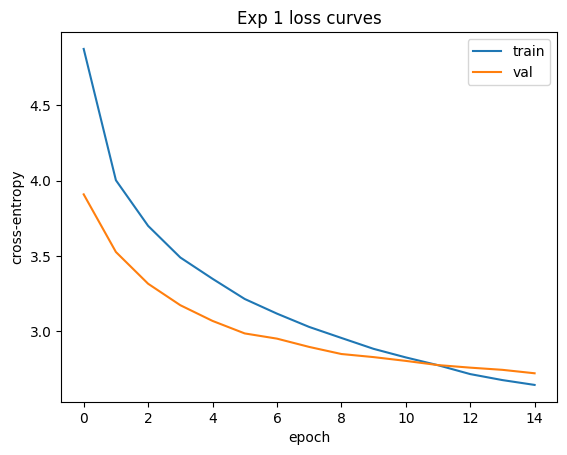

In [7]:
def run_epoch(model, loader, opt=None, tf=1.0):
    train = opt is not None
    model.train(train)
    total, n = 0.0, 0
    for src, lens, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        with torch.set_grad_enabled(train):
            logits = model(src, lens, tgt, tf if train else 1.0)
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), tgt[:, 1:].reshape(-1), ignore_index=PAD)
        if train:
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        total += loss.item(); n += 1
    return total / n

def fit(model, epochs=15, lr=1e-3, tf=0.8, patience=3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    hist, best, best_state, bad = [], 1e9, None, 0
    for ep in range(1, epochs + 1):
        t0 = time.time()
        tr, va = run_epoch(model, train_dl, opt, tf), run_epoch(model, val_dl)
        hist.append((tr, va))
        print(f"epoch {ep:2d} | train {tr:.3f} | val {va:.3f} (ppl {math.exp(va):.1f}) | {time.time()-t0:.0f}s")
        if va < best: best, best_state, bad = va, copy.deepcopy(model.state_dict()), 0
        else:
            bad += 1
            if bad >= patience: print("early stop"); break
    model.load_state_dict(best_state)
    return hist

history = fit(model, epochs=15)
plt.plot([h[0] for h in history], label="train"); plt.plot([h[1] for h in history], label="val")
plt.xlabel("epoch"); plt.ylabel("cross-entropy"); plt.legend(); plt.title("Exp 1 loss curves"); plt.show()

## 5. Greedy decoding + BLEU on the held-out test split

In [10]:
def corpus_bleu(hyps, refs):
    # we tokenised ourselves, so tell sacreBLEU not to re-tokenise
    return sacrebleu.corpus_bleu(hyps, [refs], tokenize="none").score

@torch.no_grad()
def greedy_batch(model, src, lens, max_len=60):
    model.eval()
    h, c = model.enc(src, lens)
    B = src.size(0)
    tok = torch.full((B,), SOS, device=device)
    outs, done = [], torch.zeros(B, dtype=torch.bool, device=device)
    for _ in range(max_len):
        lg, h, c = model.dec(tok, h, c)
        tok = lg.argmax(-1); outs.append(tok); done |= tok == EOS
        if done.all(): break
    return torch.stack(outs, 1).tolist()

def translate_all(model, loader):
    hyps = []
    for src, lens, _ in loader:
        for ids in greedy_batch(model, src.to(device), lens):
            hyps.append(tgt_vocab.decode(ids))
    return hyps

hyp_toks = translate_all(model, test_dl)
hyps = [" ".join(h) for h in hyp_toks]
refs = [" ".join(it["tgt_tok"]) for it in test_items]
test_bleu = corpus_bleu(hyps, refs)
print(f"Test BLEU (no attention, greedy): {test_bleu:.2f}")
for i in range(5):
    print("SRC:", " ".join(test_items[i]["src_tok"])); print("REF:", refs[i]); print("HYP:", hyps[i]); print()

Test BLEU (no attention, greedy): 16.89
SRC: several years ago here at ted , peter skillman introduced a design challenge called the marshmallow challenge .
REF: il y a plusieurs années , ici à ted , peter skillman a présenté une épreuve de conception appelée l ' épreuve du marshmallow .
HYP: il y a quelques années ici , à ted , ted , <unk> <unk> , qui a été un projet de design <unk> .

SRC: and the idea ' s pretty simple : teams of four have to build the tallest free - standing structure out of 20 sticks of spaghetti , one yard of tape , one yard of string and a marshmallow .
REF: et l ' idée est plutôt simple . des équipes de quatre personnes doivent bâtir la plus haute structure tenant debout avec 20 spaghettis , un mètre de ruban collant , un mètre de ficelle , et un marshmallow .
HYP: et l ' idée est très simple : les ' on peut faire des pièces de de la de la <unk> de la <unk> de la surface , une couche de <unk> , un arbre et un arbre .

SRC: the marshmallow has to be on top .
REF

## 6. Failure-mode analysis
Test three hypotheses: (a) quality drops on **long** sentences (fixed-size context bottleneck), (b) rare/unknown words hurt, (c) the decoder repeats itself / loses track of the source.

  source length  #sentences       BLEU
0           1-5         372  29.539561
1          6-10        1674  25.353352
2         11-15        1777  21.029974
3         16-20        1461  17.175327
4         21-40        2302  13.250328


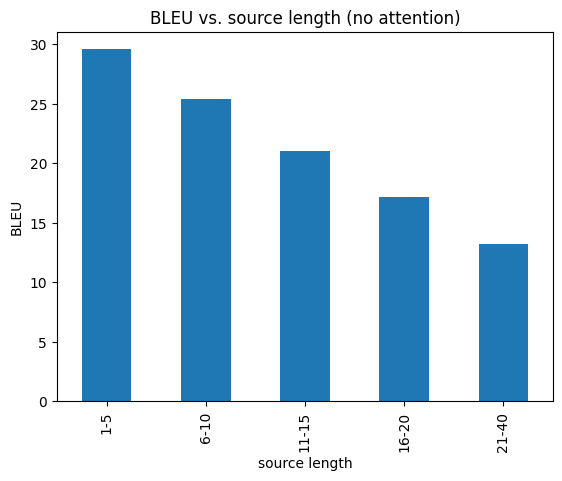


BLEU, sentences with 0 unknown source words : 18.32 (n=5901)
BLEU, sentences with >=1 unknown source word: 12.83 (n=1685)

% hypotheses with a repeated trigram: 20.9
% hypotheses containing <unk>         : 40.6
mean hyp/ref length ratio             : 0.97


In [11]:
src_len = np.array([len(it["src_tok"]) for it in test_items])
n_unk = np.array([sum(t not in src_vocab.stoi for t in it["src_tok"]) for it in test_items])
hyps_a, refs_a = np.array(hyps, dtype=object), np.array(refs, dtype=object)

def bucket_bleu(mask):
    return corpus_bleu(list(hyps_a[mask]), list(refs_a[mask])) if mask.sum() >= 10 else float("nan")

edges = [(1, 5), (6, 10), (11, 15), (16, 20), (21, MAX_LEN)]
rows = [(f"{a}-{b}", int(((src_len >= a) & (src_len <= b)).sum()), bucket_bleu((src_len >= a) & (src_len <= b))) for a, b in edges]
len_df = pd.DataFrame(rows, columns=["source length", "#sentences", "BLEU"]); print(len_df)
len_df.plot(x="source length", y="BLEU", kind="bar", legend=False, title="BLEU vs. source length (no attention)"); plt.ylabel("BLEU"); plt.show()

print("\nBLEU, sentences with 0 unknown source words :", round(bucket_bleu(n_unk == 0), 2), f"(n={(n_unk==0).sum()})")
print("BLEU, sentences with >=1 unknown source word:", round(bucket_bleu(n_unk >= 1), 2), f"(n={(n_unk>=1).sum()})")

def has_repeat(toks, n=3):
    grams = [tuple(toks[i:i+n]) for i in range(len(toks) - n + 1)]
    return len(grams) != len(set(grams))
print("\n% hypotheses with a repeated trigram:", round(100 * np.mean([has_repeat(h) for h in hyp_toks]), 1))
print("% hypotheses containing <unk>         :", round(100 * np.mean(["<unk>" in h for h in hyp_toks]), 1))
ratio = np.array([len(h) / max(1, len(it["tgt_tok"])) for h, it in zip(hyp_toks, test_items)])
print("mean hyp/ref length ratio             :", round(ratio.mean(), 2))

In [12]:
os.makedirs("results", exist_ok=True)
json.dump({"exp": 1, "model": "LSTM enc-dec, no attention", "test_bleu_greedy": test_bleu,
           "bleu_by_length": len_df.to_dict("records")}, open("results/exp1.json", "w"), indent=1, default=float)
torch.save({"model": model.state_dict()}, "results/exp1_model.pt")

## Conclusion
* The training loss decreased over the epochs, showing that the model learned the translation patterns from the training data.
* The validation loss also decreased, indicating that the model was able to generalize to unseen validation data.
* Cross-entropy loss effectively measured the error between the predicted and actual target tokens.
* Early stopping was used to prevent unnecessary training once validation performance stopped improving.
* The final test BLEU score was 16.89, showing that the generated translations had some similarity to the reference translations.
* BLEU decreased as source sentence length increased:
  + 1-5 words: 29.54
  + 6-10 words: 25.35
  + 11-15 words: 21.03
  + 16-20 words: 17.18
  + 21-40 words: 13.25
* This shows that the model performs better on shorter sentences and struggles more with longer sentences.
* The results highlight the limitation of the basic Seq2Seq model without attention, motivating the use of an attention mechanism for better handling of longer sequences.
* Sentences with no unknown (<UNK>) source words achieved a BLEU of 18.32, while sentences with one or more unknown words achieved a lower BLEU of 12.83.
* 40.6% of the generated hypotheses contained <UNK>, indicating that unknown vocabulary significantly affected the translations.
* 20.9% of the hypotheses contained repeated trigrams, showing some repetition in the generated translations.
* The mean hypothesis/reference length ratio was 0.97, indicating that the generated translations were, on average, close to the reference length.
* Overall, the results show that the model learned the translation task but performs worse with longer sentences and unknown words, highlighting the limitations of the basic Seq2Seq architecture without attention.